In [2]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import torch
import torch.nn as nn
import torch.optim as optim


环境配置正常


In [3]:
def tensor_print(t , num=0):
    print(f"{t} , type:{type(t)}" , end='')
    try:
        print(f' row:{t.shape[0]} , columns:{t.shape[1]} , last:{t.shape[-1]}')
    except Exception as e:
        print('t.shape:',t.shape)        
    if num != 0:
        print('-' * 15,end='')
        print(f' 第{num}项如上',end='')
        print('-' * 15)
    else:
        print('-'*30)

<font color = #000000 >

## 1-1 梯度下降算法回顾

+ 学习率太小效果不好
+ 学习率太大可能会跳过最优解
+ batch size : 一轮的批次

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-18-52-47.png" style="width:60%;"></p>

</font>

<font color = #000000 >

## 1-2 反向传播(BP算法)

+ 整体梯度更新流程 神经网络

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-18-47-48.png" style="width:60%;"></p>

+ 前向传播运算过程

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-18-48-21.png" style="width:60%;"></p>

+ 反向传播运算过程

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-18-51-00.png" style="width:60%;"></p>

</font>

<font color = #000000 >

## 2-0 指数移动加权平均介绍

+ β 越大 , 越依赖历史数据,更加平稳

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-19-03-17.png" style="width:60%;"></p>

四种梯度下降优化方法:

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-20-10-48.png" style="width:80%;"></p>

</font>

<font color = #000000 >

## 2-1 梯度下降优化方法-动量法

+ 动量法momentum: St = β * St-1 + (1-β) * Gt

+ 新的梯度更新公式: w新 = w旧 - 学习率 * St

</font>

In [4]:
# 1. 梯度下降优化方法: 动量法
# 1-1 初始化权重参数
w = torch.tensor([1.0] , requires_grad=True , dtype=torch.float)
# 1-2 定义损失函数
criterion = w ** 2 / 2.0
# 1-3 创建优化器(用于梯度更新)(基于SGD(梯度随机下降)),加入参数 momentum ,就是动量法
optimizer = optim.SGD([w] , lr=0.01 , momentum=0.9)
# 1-4 计算梯度值: 梯度清零 + 反向传播 + 参数更新
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

# 1-5 重复上述步骤
criterion = w ** 2 / 2.0
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

w:tensor([0.9900], requires_grad=True) , w.grad:tensor([1.])
w:tensor([0.9711], requires_grad=True) , w.grad:tensor([0.9900])


<font color = #000000 >

## 2-2 梯度下降优化方法-adaGrad

+ AdaGrad:
+ 公式: St = St-1 + Gt * Gt(本次梯度)
+ 学习率 = 学习率 / ( sqrt(St) + 小常量 )

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-19-47-22.png" style="width:60%;"></p>

</font>

In [5]:
# 2. 梯度下降优化方法: AdaGrad
# 1-1 初始化权重参数
w = torch.tensor([1.0] , requires_grad=True , dtype=torch.float)
# 1-2 定义损失函数
criterion = w ** 2 / 2.0
# 1-3 创建优化器, 基于AdaGrad

optimizer = optim.Adagrad([w] , lr=0.01)

# 1-4 计算梯度值: 梯度清零 + 反向传播 + 参数更新
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

# 1-5 重复上述步骤
criterion = w ** 2 / 2.0
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

w:tensor([0.9900], requires_grad=True) , w.grad:tensor([1.])
w:tensor([0.9830], requires_grad=True) , w.grad:tensor([0.9900])


<font color = #000000 >

## 2-3 梯度下降优化方法-RMSProp

+ RMSProp:(对AdaGrad的优化)
+ 公式: St = β * St-1 + (1 - β) * Gt * Gt(本次梯度)
+ 学习率 = 学习率 / ( sqrt(St) + 小常量 )
+ RMSProp 通过引入衰减系数β, 控制历史梯度 对 历史梯度信息获取的多少

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-19-54-36.png" style="width:60%;"></p>

</font>

In [6]:
# 3. 梯度下降优化方法: RMSProp: 可以看成是对AdaGrad的优化
# 1-1 初始化权重参数
w = torch.tensor([1.0] , requires_grad=True , dtype=torch.float)
# 1-2 定义损失函数
criterion = w ** 2 / 2.0

# 1-3 创建优化器, 基于AdaGrad

optimizer = optim.RMSprop(params=[w] , lr=0.01 , alpha=0.99)

# 1-4 计算梯度值: 梯度清零 + 反向传播 + 参数更新
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

# 1-5 重复上述步骤
criterion = w ** 2 / 2.0
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

w:tensor([0.9000], requires_grad=True) , w.grad:tensor([1.])
w:tensor([0.8329], requires_grad=True) , w.grad:tensor([0.9000])


<font color = #000000 >

## 2-4 梯度下降优化方法-Adam

+ `修正梯度 + 修正学习率 (是Momentum和RMSProp的结合)`
    + 既优化学习率 右优化梯度
    + 参数: β1 , β2 , 小参数

<p align="left"><img src="梯度下降-学习率-正则化.assets/2026-03-18-20-04-52.png" style="width:40%;"></p>

</font>

In [7]:
# 3. 梯度下降优化方法: Adam
# 1-1 初始化权重参数
w = torch.tensor([1.0] , requires_grad=True , dtype=torch.float)
# 1-2 定义损失函数
criterion = w ** 2 / 2.0

# 1-3 创建优化器, 基于AdaGrad

optimizer = optim.Adam(params=[w] , lr=0.01 , betas=(0.9,0.999))    # betas = (梯度用的衰减系数 , 学习率用的衰减系数)

# 1-4 计算梯度值: 梯度清零 + 反向传播 + 参数更新
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

# 1-5 重复上述步骤
criterion = w ** 2 / 2.0
optimizer.zero_grad()
criterion.sum().backward()
optimizer.step()
print(f'w:{w} , w.grad:{w.grad}')

w:tensor([0.9900], requires_grad=True) , w.grad:tensor([1.])
w:tensor([0.9800], requires_grad=True) , w.grad:tensor([0.9900])


<font color = #000000 >

## 3-1 学习率衰减方法-等间隔学习率衰减

<p align="left"><img src="梯度下降-学习率-正则化.assets/2026-03-18-20-22-14.png" style="width:60%;"></p>

</font>

lr_list:[[0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025], [0.025]

C:\Users\lxl\AppData\Local\Temp\ipykernel_23280\3180158120.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


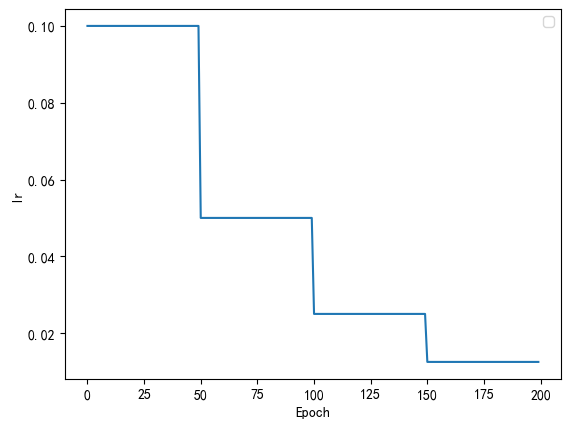

In [8]:
# 1. 等间隔学习率衰减

# 1-1 定义变量,初始化
lr , epochs , iteration = 0.1 , 200 , 100

# 1-2 创建数据集, y_true , x ,w 
y_true = torch.tensor([0])
x = torch.tensor([1.0] , dtype=torch.float)
w = torch.tensor([1.0] , dtype=torch.float , requires_grad=True)

# 1-3 创建优化器对象,动量法
optimizer = optim.SGD(params=[w] , lr=lr , momentum=0.9)

# 1-4 创建学习率衰减对象
# 思路1: 等间隔衰减学习率
# optimizer: 优化器对象 step_size: 多少轮调整一次学习率 gamma学习率衰减系数: 新 = 旧 * gamma
scheduler = optim.lr_scheduler.StepLR(optimizer , step_size=50 , gamma=0.5)

# 1-5 创建列表接收数据
lr_list , epoch_list = [] , []

# 1-6 循环遍历训练轮数
for epoch in range(epochs):
    # 训练200轮
    # 1. 获取当前轮数和学习率
    epoch_list.append(epoch)
    lr_list.append(scheduler.get_last_lr()) # 获取当前最后的学习率

    # 2. 循环遍历, 每轮每批次进行训练(每轮iteration(10)批)
    for batch in range(iteration):
        # 计算预测值
        y_pred = w * x # 暂时忽略bias
        # 计算损失
        loss = (y_pred - y_true) ** 2
        # 梯度清零 + 反向传播 + 梯度更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # 梯度更新
    
    # 更新学习率
    scheduler.step()     # 学习率更新

# 1-7打印结果
print(f'lr_list:{lr_list}')

# 1-8 可视化
# x轴:训练的轮数 , y轴: 每轮训练用的学习率
plt.plot(epoch_list , lr_list)
plt.xlabel('Epoch')
plt.ylabel('lr')
plt.legend()
plt.show()


<font color = #000000 >

## 3-2 学习率衰减方法-指定间隔学习率衰减

+ 修改一句话就好: 思路2


</font>

lr_list:[[0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.1], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.05], [0.025], [0.025], [0.025], [0.025], [0.02

C:\Users\lxl\AppData\Local\Temp\ipykernel_23280\21321087.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


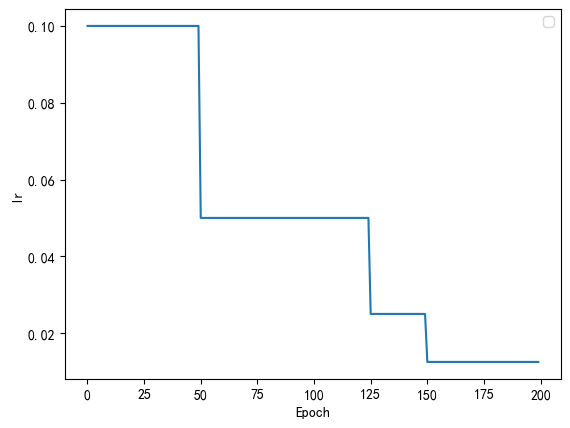

In [9]:
# 1. 指定间隔学习率衰减

# 1-1 定义变量,初始化
lr , epochs , iteration = 0.1 , 200 , 100

# 1-2 创建数据集, y_true , x ,w 
y_true = torch.tensor([0])
x = torch.tensor([1.0] , dtype=torch.float)
w = torch.tensor([1.0] , dtype=torch.float , requires_grad=True)

# 1-3 创建优化器对象,动量法
optimizer = optim.SGD(params=[w] , lr=lr , momentum=0.9)

# 1-4 创建学习率衰减对象
# 思路1: 等间隔衰减学习率
# optimizer: 优化器对象 step_size: 多少轮调整一次学习率 gamma学习率衰减系数: 新 = 旧 * gamma
# scheduler = optim.lr_scheduler.StepLR(optimizer , step_size=50 , gamma=0.5)

# 思路2: 制定间隔衰减学习率
scheduler = optim.lr_scheduler.MultiStepLR(optimizer , milestones=[50,125,150] , gamma=0.5)

# 1-5 创建列表接收数据
lr_list , epoch_list = [] , []

# 1-6 循环遍历训练轮数
for epoch in range(epochs):
    # 训练200轮
    # 1. 获取当前轮数和学习率
    epoch_list.append(epoch)
    lr_list.append(scheduler.get_last_lr()) # 获取当前最后的学习率

    # 2. 循环遍历, 每轮每批次进行训练(每轮iteration(10)批)
    for batch in range(iteration):
        # 计算预测值
        y_pred = w * x # 暂时忽略bias
        # 计算损失
        loss = (y_pred - y_true) ** 2
        # 梯度清零 + 反向传播 + 梯度更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # 梯度更新
    
    # 更新学习率
    scheduler.step()     # 学习率更新

# 1-7打印结果
print(f'lr_list:{lr_list}')

# 1-8 可视化
# x轴:训练的轮数 , y轴: 每轮训练用的学习率
plt.plot(epoch_list , lr_list)
plt.xlabel('Epoch')
plt.ylabel('lr')
plt.legend()
plt.show()


<font color = #000000 >

## 3-3 学习率衰减方法-按指数学习率衰减

+ 就是每次为原来的指数次方: 新 = 旧^n
+ 特点: 前期衰减快,中期慢,后期更慢

</font>

lr_list:[[0.1], [0.095], [0.09025], [0.0857375], [0.08145062499999998], [0.07737809374999999], [0.07350918906249998], [0.06983372960937498], [0.06634204312890622], [0.0630249409724609], [0.05987369392383786], [0.05688000922764597], [0.05403600876626367], [0.05133420832795048], [0.04876749791155295], [0.046329123015975304], [0.04401266686517654], [0.04181203352191771], [0.039721431845821824], [0.037735360253530734], [0.035848592240854196], [0.03405616262881148], [0.03235335449737091], [0.030735686772502362], [0.029198902433877242], [0.027738957312183378], [0.026352009446574207], [0.025034408974245494], [0.023782688525533217], [0.022593554099256556], [0.021463876394293726], [0.020390682574579037], [0.019371148445850084], [0.01840259102355758], [0.0174824614723797], [0.016608338398760712], [0.015777921478822676], [0.014989025404881541], [0.014239574134637464], [0.01352759542790559], [0.012851215656510309], [0.012208654873684792], [0.011598222130000552], [0.011018311023500524], [0.01046739

C:\Users\lxl\AppData\Local\Temp\ipykernel_23280\3179220804.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


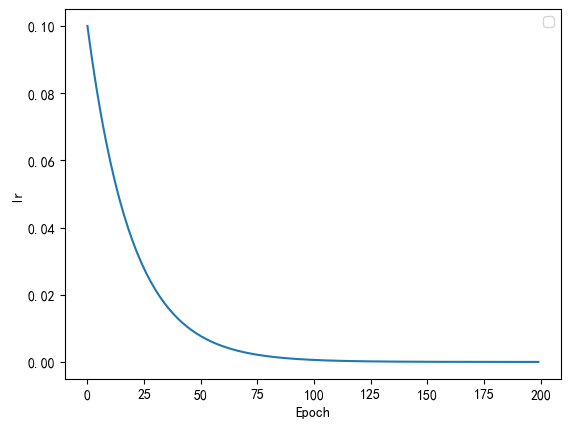

In [10]:
# 3. 按指数学习率衰减

# 1-1 定义变量,初始化
lr , epochs , iteration = 0.1 , 200 , 100

# 1-2 创建数据集, y_true , x ,w 
y_true = torch.tensor([0])
x = torch.tensor([1.0] , dtype=torch.float)
w = torch.tensor([1.0] , dtype=torch.float , requires_grad=True)

# 1-3 创建优化器对象,动量法
optimizer = optim.SGD(params=[w] , lr=lr , momentum=0.9)

# 1-4 创建学习率衰减对象
# 思路1: 等间隔衰减学习率
# optimizer: 优化器对象 step_size: 多少轮调整一次学习率 gamma学习率衰减系数: 新 = 旧 * gamma
# scheduler = optim.lr_scheduler.StepLR(optimizer , step_size=50 , gamma=0.5)

# 思路2: 制定间隔衰减学习率
# scheduler = optim.lr_scheduler.MultiStepLR(optimizer , milestones=[50,125,150] , gamma=0.5)

# 思路3: 按指数学习率衰减
scheduler = optim.lr_scheduler.ExponentialLR(optimizer , gamma=0.95)

# 1-5 创建列表接收数据
lr_list , epoch_list = [] , []

# 1-6 循环遍历训练轮数
for epoch in range(epochs):
    # 训练200轮
    # 1. 获取当前轮数和学习率
    epoch_list.append(epoch)
    lr_list.append(scheduler.get_last_lr()) # 获取当前最后的学习率

    # 2. 循环遍历, 每轮每批次进行训练(每轮iteration(10)批)
    for batch in range(iteration):
        # 计算预测值
        y_pred = w * x # 暂时忽略bias
        # 计算损失
        loss = (y_pred - y_true) ** 2
        # 梯度清零 + 反向传播 + 梯度更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() # 梯度更新
    
    # 更新学习率
    scheduler.step()     # 学习率更新

# 1-7打印结果
print(f'lr_list:{lr_list}')

# 1-8 可视化
# x轴:训练的轮数 , y轴: 每轮训练用的学习率
plt.plot(epoch_list , lr_list)
plt.xlabel('Epoch')
plt.ylabel('lr')
plt.legend()
plt.show()


<font color = #000000 >

## 4-1 正则化方法-dropout

+ 正则化的作用: 缓解模型的过拟合情况

+ 正则化的方式:
    + L1正则化:权重可以变为0,相当于:降维
    + L2正购化：权重可以无限接近0
    + DropOut：随机失活,每批次样本训练时,随机让一部分神经元死亡
    + BN(批量归一化)

</font>

In [11]:
# 1. 创建隐藏层输出结果
t1 = torch.randint(0,10,size=(1,4)).float()
tensor_print(t1)
# 2. 进行下一层 加权求和 + 激活函数 计算
Liner1 = nn.Linear(4,5) # in 4 out 5
l1 = Liner1(t1)
print(l1)
output = torch.relu(l1)
print(output)

# 3. 随机失活, 只有训练阶段采用,测试阶段没有
dropout = nn.Dropout(p=0.4) # 失活概率
d1 = dropout(output)    # 未被失活的进行缩放,缩放乘以 1 / (1 - p)
print(d1)

tensor([[8., 0., 0., 4.]]) , type:<class 'torch.Tensor'> row:1 , columns:4 , last:4
------------------------------
tensor([[-0.4286,  1.5648,  0.3686, -1.5729, -2.9521]],
       grad_fn=<AddmmBackward0>)
tensor([[0.0000, 1.5648, 0.3686, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)
tensor([[0.0000, 2.6079, 0.0000, 0.0000, 0.0000]], grad_fn=<MulBackward0>)


<font color = #000000 >

## 4-2 正则化方法-批量归一化(BN)

<p align="center"><img src="梯度下降-学习率-正则化.assets/2026-03-18-21-14-22.png" style="width:60%;"></p>

+ 正则化的方式:
    + L1正则化:权重可以变为0,相当于:降维
    + L2正购化：权重可以无限接近0
    + DropOut：随机失活,每批次样本训练时,随机让一部分神经元死亡
    + BN(批量归一化)

</font>

In [13]:
# 批量归一化: 环节模型过拟合

'''
思路:
    先对数据标准化(丢失一些信息,然后对数据做缩放(λ,理解为w)和平移b),再找补回来一些信息
'''

# 1. 定义函数,处理二维数据
input_2d = torch.randn(size=(1,2,3,4))  # 1张图片,两个通道,3行4列(像素点)
tensor_print(input_2d)

# 2. 创建批量归一化层(BN层)
# num_features: 图片的通道量 eps: 噪声值 momentum:动量值 affine:变换参数(λ,β),对标准化后的数据进行平移缩放
bn2d = nn.BatchNorm2d(num_features=2,eps=1e-5,momentum=0.1,affine=True)

# 3. 对数据进行批量归一化处理
ootput_2d = bn2d(input_2d)
tensor_print(ootput_2d)

tensor([[[[ 0.9842,  0.3107, -1.2747,  0.6760],
          [ 0.0492, -0.1678, -0.0838,  0.7986],
          [-1.0433,  1.0027,  0.1438,  0.4509]],

         [[-1.4082, -2.3697,  1.4790,  1.1122],
          [ 0.7010, -1.5493,  0.1708, -0.5552],
          [-0.7809,  0.2393, -0.2396,  0.3491]]]]) , type:<class 'torch.Tensor'> row:1 , columns:2 , last:4
------------------------------
tensor([[[[ 1.1885e+00,  2.2448e-01, -2.0450e+00,  7.4737e-01],
          [-1.4990e-01, -4.6043e-01, -3.4018e-01,  9.2288e-01],
          [-1.7137e+00,  1.2151e+00, -1.4419e-02,  4.2521e-01]],

         [[-1.0678e+00, -1.9449e+00,  1.5659e+00,  1.2313e+00],
          [ 8.5626e-01, -1.1965e+00,  3.7256e-01, -2.8971e-01],
          [-4.9554e-01,  4.3503e-01, -1.7942e-03,  5.3519e-01]]]],
       grad_fn=<NativeBatchNormBackward0>) , type:<class 'torch.Tensor'> row:1 , columns:2 , last:4
------------------------------


In [23]:
# BN处理一维数据
input_1d = torch.randn(size=(2,2))
tensor_print(input_1d , 1)

# 创建线性层
Linear1 = nn.Linear(2, 4)

# 线性变换
L1 = Linear1(input_1d)

# 创建批量归一化层
bn1d = nn.BatchNorm1d(num_features=4)
ootput_1d = bn1d(L1)

tensor_print(ootput_1d , 2)



tensor([[-0.1516, -0.3402],
        [ 0.1750,  0.4600]]) , type:<class 'torch.Tensor'> row:2 , columns:2 , last:2
--------------- 第1项如上---------------
tensor([[ 0.9999, -0.9999,  0.9999, -0.9997],
        [-0.9999,  0.9999, -0.9999,  0.9997]],
       grad_fn=<NativeBatchNormBackward0>) , type:<class 'torch.Tensor'> row:2 , columns:4 , last:4
--------------- 第2项如上---------------
